### **KLASIFIKASI SPEECH EMOTION ANNOTATED DATA FOR EMOTION RECOGNITION SYSTEMS**
(SAVEE DATASET)


### Business Understanding

**Latar Belakang Masalah**
Dalam interaksi manusia dan komputer (*Human-Computer Interaction*), mesin saat ini sudah sangat mahir dalam memahami *apa* yang diucapkan melalui teknologi *Speech-to-Text*, namun masih kesulitan memahami *bagaimana* hal itu diucapkan (konteks emosional). Sebuah perintah yang diucapkan dengan nada marah seringkali diproses dengan respons yang sama persis saat diucapkan dengan nada gembira. Oleh karena itu, diperlukan sistem yang mampu mengenali pola emosi melalui sinyal akustik untuk menjembatani celah empati pada kecerdasan buatan.

**Tujuan Proyek**
Sebagai bagian dari pemenuhan proyek akhir Pengenalan Pola, eksperimen ini bertujuan untuk:
1. Membangun model klasifikasi *Speech Emotion Recognition* (SER).
2. Melakukan ekstraksi representasi fitur suara menggunakan *Mel-Frequency Cepstral Coefficients* (MFCC).
3. Mengklasifikasikan 7 jenis emosi (*Anger, Disgust, Fear, Happiness, Neutral, Sadness, Surprise*) secara akurat menggunakan arsitektur 1D *Convolutional Neural Network* dari dataset SAVEE (*Surrey Audio-Visual Expressed Emotion*).

**Peluang Penerapan (Use Case)**
Model pengenalan pola emosi yang dikembangkan ini merepresentasikan logika dasar yang dapat diintegrasikan ke dalam sistem perangkat lunak yang lebih besar, seperti:
* **Analisis Layanan Pelanggan (*Call Center*):** Secara otomatis mendeteksi pelanggan dengan eskalasi emosi marah agar sistem memprioritaskan penanganan oleh operator manusia.
* **Asisten Virtual Cerdas:** Memungkinkan AI memberikan respons atau rekomendasi yang disesuaikan dengan kondisi psikologis pengguna saat itu.

In [ ]:
!pip install librosa soundfile numpy scikit-learn tensorflow matplotlib seaborn

import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# Upload file kaggle.json
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Silakan upload file kaggle.json Anda:")
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d barelydedicated/savee-database
# Ekstrak dataset
!unzip -q savee-database.zip -d savee_dataset
print("Dataset berhasil diunduh dan diekstrak!")

Silakan upload file kaggle.json Anda:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/barelydedicated/savee-database
License(s): copyright-authors
100% 215M/215M [00:01<00:00, 118MB/s]

Dataset berhasil diunduh dan diekstrak!


Data Understanding & Labelling (CRISP-DM: Data Understanding)
Dataset SAVEE memiliki konvensi penamaan file yang spesifik di mana huruf pada nama file menunjukkan emosi (misal: 'a' = anger, 'd' = disgust, 'f' = fear, 'h' = happiness, 'n' = neutral, 'sa' = sadness, 'su' = surprise). Kita akan melakukan parsing pada direktori untuk membuat DataFrame.

Total data: 480 file audio.
Emotion
Neutral      120
Fear          60
Surprise      60
Happiness     60
Sadness       60
Anger         60
Disgust       60
Name: count, dtype: int64


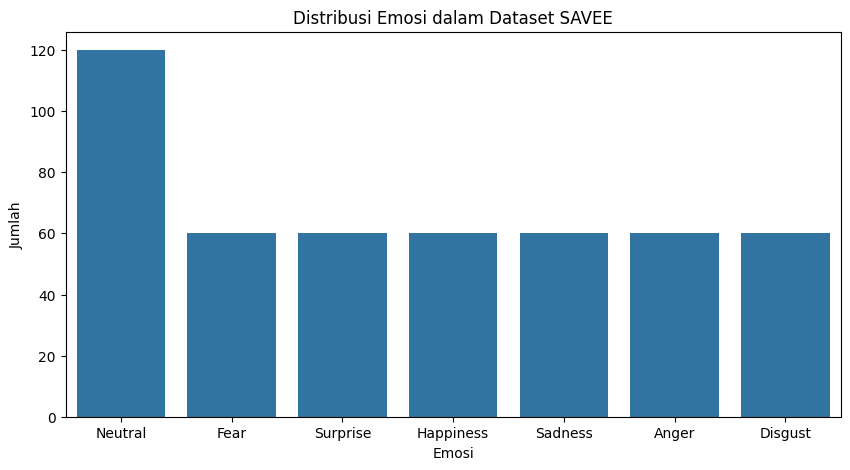

In [ ]:
# Path menuju folder audio (sesuaikan dengan struktur hasil ekstrak)
base_path = 'savee_dataset/AudioData/'

file_paths = []
labels = []

# Loop untuk membaca file di dalam folder aktor (DC, JE, JK, KL)
for actor_dir in os.listdir(base_path):
    actor_path = os.path.join(base_path, actor_dir)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                file_paths.append(os.path.join(actor_path, file))

                # Mengambil kode emosi dari nama file
                filename = file.split('.')[0]
                # Menghilangkan angka di akhir (misal: a01 -> a, sa02 -> sa)
                emotion_code = ''.join([i for i in filename if not i.isdigit()])

                # Mapping kode ke nama emosi penuh
                if emotion_code == 'a': labels.append('Anger')
                elif emotion_code == 'd': labels.append('Disgust')
                elif emotion_code == 'f': labels.append('Fear')
                elif emotion_code == 'h': labels.append('Happiness')
                elif emotion_code == 'n': labels.append('Neutral')
                elif emotion_code == 'sa': labels.append('Sadness')
                elif emotion_code == 'su': labels.append('Surprise')

df = pd.DataFrame({'Path': file_paths, 'Emotion': labels})
print(f"Total data: {df.shape[0]} file audio.")
print(df['Emotion'].value_counts())

# Visualisasi Distribusi Kelas (Sangat penting untuk laporan CRISP-DM)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Emotion', order=df['Emotion'].value_counts().index)
plt.title('Distribusi Emosi dalam Dataset SAVEE')
plt.xlabel('Emosi')
plt.ylabel('Jumlah')
plt.show()

Visualisasi Sinyal Audio (CRISP-DM: Data Understanding - Visualization)
Menampilkan bentuk gelombang (Waveform) dan Spectrogram dari salah satu file untuk memahami karakteristik fisik dari data suara.

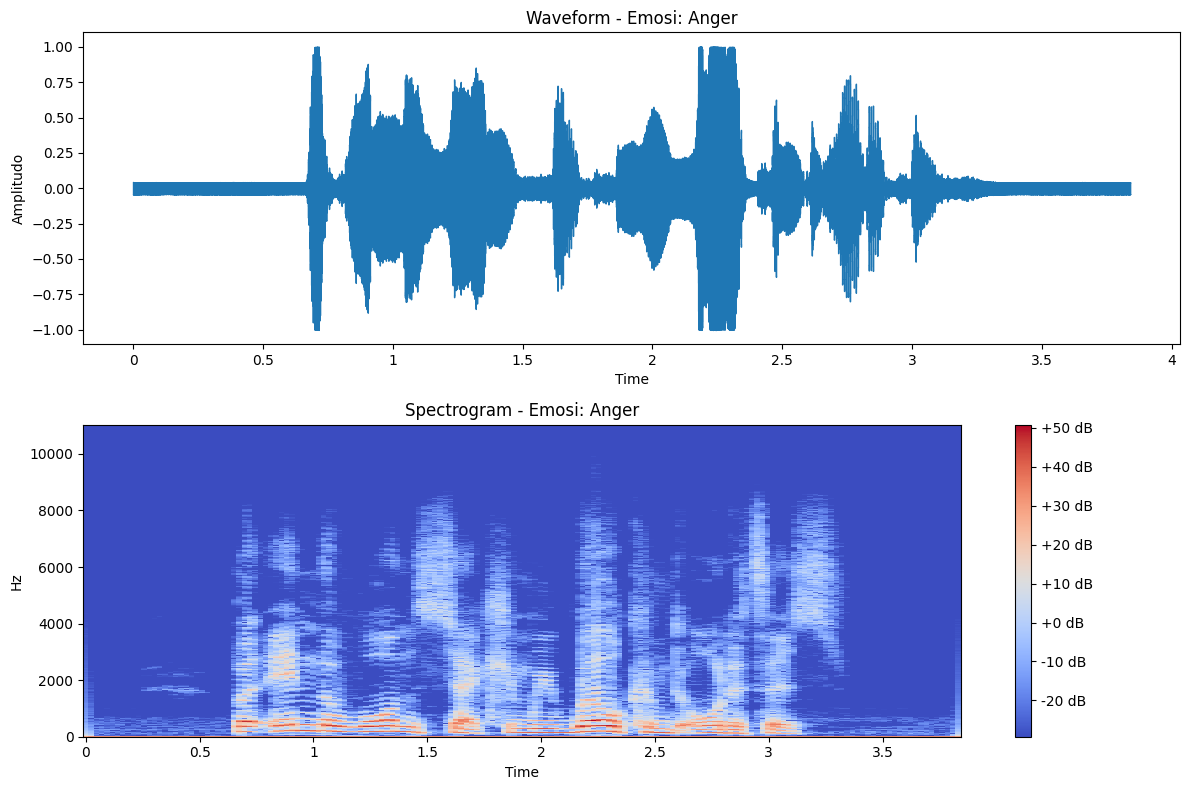

In [ ]:
# Mengambil sampel salah satu file audio emosi 'Anger'
sample_path = df[df['Emotion'] == 'Anger']['Path'].iloc[0]
y, sr = librosa.load(sample_path)

plt.figure(figsize=(12, 8))

# Plot Waveform
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform - Emosi: Anger')
plt.ylabel('Amplitudo')

# Plot Spectrogram
plt.subplot(2, 1, 2)
X = librosa.stft(y)
Xdb = librosa.amplitude_to_db(abs(X))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram - Emosi: Anger')

plt.tight_layout()
plt.show()

In [ ]:
!pip install resampy

Ekstraksi Fitur MFCC (CRISP-DM: Data Preparation)
Mengubah seluruh file audio menjadi array numerik berbasis nilai rata-rata MFCC.

In [ ]:
def extract_mfcc(file_path, n_mfcc=40):
    # Load audio tanpa parameter res_type agar tidak memicu error resampy
    y, sr = librosa.load(file_path)

    # Ekstraksi MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Mengambil nilai rata-rata sepanjang waktu (axis=1) agar dimensi konsisten
    mfccs_processed = np.mean(mfccs.T, axis=0)
    return mfccs_processed

print("Memulai ekstraksi fitur MFCC... (Proses ini memakan waktu beberapa menit)")
X_features = np.array([extract_mfcc(path) for path in df['Path']])
y_labels = np.array(df['Emotion'])
print("Ekstraksi fitur selesai!")
print(f"Dimensi matriks fitur X: {X_features.shape}")

Memulai ekstraksi fitur MFCC... (Proses ini memakan waktu beberapa menit)
Ekstraksi fitur selesai!
Dimensi matriks fitur X: (480, 40)


Split Data & Encoding (CRISP-DM: Data Preparation)
Membagi data menjadi data latih (training) dan data uji (testing), serta melakukan normalisasi nilai fitur.

In [ ]:
# Mengubah label teks menjadi representasi angka
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Standarisasi Fitur agar skala nilainya seragam
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape untuk input ke 1D CNN (Jumlah Sampel, Jumlah Fitur, 1)
X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)

print(f"Struktur Data Train untuk CNN: {X_train_cnn.shape}")

Struktur Data Train untuk CNN: (384, 40, 1)


Membangun Arsitektur Model 1D CNN (CRISP-DM: Modeling)
Menggunakan Convolutional Neural Network 1-Dimensi yang sangat efektif dalam mengenali pola urutan/sekuensial pada fitur audio seperti MFCC.

In [ ]:
model = models.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,159 (1.10 MB)

 Trainable params: 289,159 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

Proses Training Model (CRISP-DM: Modeling)
Melatih model dengan data training dan memvalidasinya menggunakan data testing.

In [ ]:
history = model.fit(X_train_cnn, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test_cnn, y_test))

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.2266 - loss: 1.9019 - val_accuracy: 0.3333 - val_loss: 1.6800
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3906 - loss: 1.5740 - val_accuracy: 0.4271 - val_loss: 1.4411
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4505 - loss: 1.4117 - val_accuracy: 0.4583 - val_loss: 1.3033
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4974 - loss: 1.3318 - val_accuracy: 0.4688 - val_loss: 1.2550
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 1.2255 - val_accuracy: 0.4688 - val_loss: 1.2352
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5312 - loss: 1.1802 - val_accuracy: 0.5104 - val_loss: 1.1768
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5703 - loss: 1.1177 - val_accuracy: 0.5729 - val_loss: 1.1260
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5781 - loss: 1.0732 - val_accuracy: 0.5104 - v

Evaluasi dan Visualisasi Metrik (CRISP-DM: Evaluation)
Membuat grafik akurasi/loss dan menampilkan Confusion Matrix untuk mengukur performa klasifikasi setiap emosi.

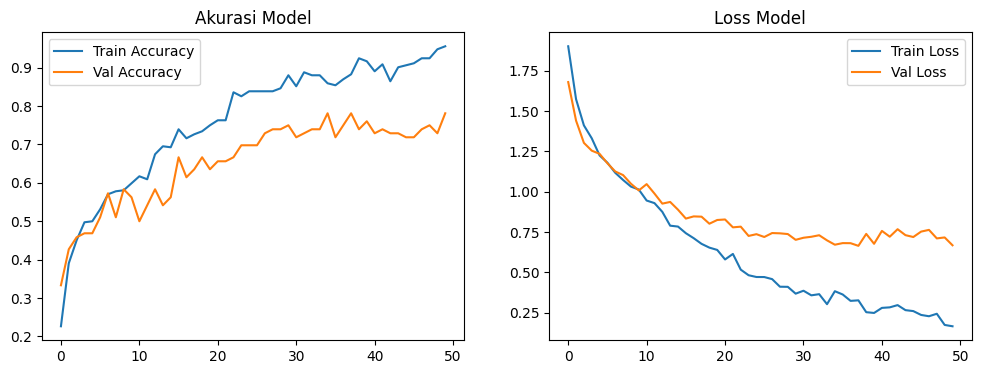

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       0.82      0.75      0.78        12
     Disgust       0.73      0.67      0.70        12
        Fear       0.73      0.67      0.70        12
   Happiness       0.69      0.75      0.72        12
     Neutral       0.92      0.92      0.92        24
     Sadness       0.75      0.75      0.75        12
    Surprise       0.71      0.83      0.77        12

    accuracy                           0.78        96
   macro avg       0.76      0.76      0.76        96
weighted avg       0.78      0.78      0.78        96



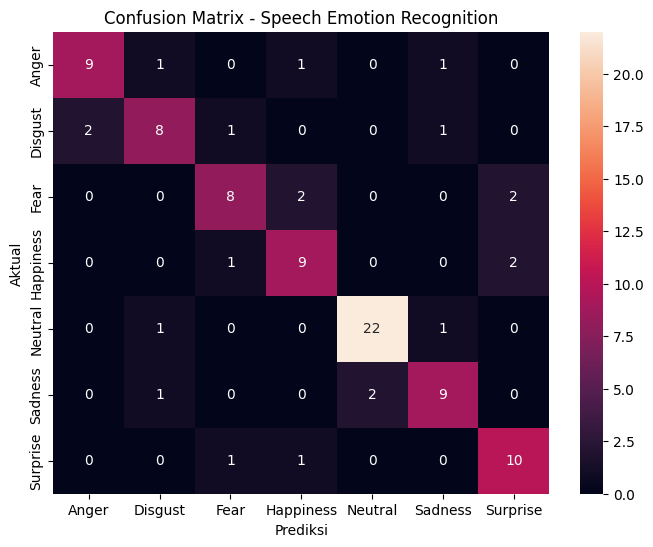

In [ ]:
# Plot Akurasi dan Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Akurasi Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.legend()
plt.show()

# Prediksi Data Test
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Speech Emotion Recognition')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()